In [31]:
from astropy.io import fits
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler

import tools as t

## Load Data

In [2]:
# load TS1
path_data = '../data/sim_series/'  # directory where the files are saved
data_spectra = fits.getdata(path_data + f'flux_norm_6173_lionel_tau1_spatialscaling1_sansrotation_serie0.fits')
data_spectra = np.array(data_spectra)

times = np.arange(0, len(data_spectra) * 144, 144) / 60 / 24  # time in days, same for all time series

In [3]:
# Parameters

N = 3686  # timesteps
M = 20  # PCs
TS = 1  # time series used

# Load data

X = []
y = []

for i in range(N):

    data = torch.load(f'../data/PCA/TS{TS}/t_{i}.pt')

    X.append(data['scores'].float())
    y.append(torch.as_tensor(data['rv'], dtype=torch.float32))

X = torch.stack(X)
y = torch.stack(y).reshape(-1, 1)

print("Total X shape:", X.shape)
print("Total y shape:", y.shape)

/tmp/ipykernel_867685/3950740032.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(f'../data/PCA/TS{TS}/t_{i}.pt')


Total X shape: torch.Size([3686, 20])
Total y shape: torch.Size([3686, 1])


In [4]:
# RV stats
print(f'Mean: {y.mean().item()}')
print(f'Sigma: {y.std().item()}')
print(f'Min: {y.min().item()}')
print(f'Max: {y.max().item()}')

Mean: -3.8809319646837537e-10
Sigma: 0.9465776681900024
Min: -3.7014224529266357
Max: 3.3682401180267334


## Arrange data

In [5]:
batch_size = 1
chunk_size = 21

# Chronological train/test split

train_size = int(0.7 * N)
# cut beginning and end of the arrays so all chunks have the same size
rest_train = train_size % chunk_size
rest_test  = (N - train_size) % chunk_size

X_train = X[rest_train:train_size]
y_train = y[rest_train:train_size]

X_test = X[train_size:-rest_test]
y_test = y[train_size:-rest_test]

# scale scores (X)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.numpy())
X_train = torch.tensor(X_train_scaled, dtype=torch.float32)

X_test_scaled = scaler.transform(X_test.numpy())
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)

# reshape into chunks
X_train = X_train.reshape((-1, chunk_size, M))
y_train = y_train.reshape((-1, chunk_size, 1))

X_test = X_test.reshape((-1, chunk_size, M))
y_test = y_test.reshape((-1, chunk_size, 1))

print("Train X shape:", X_train.shape)
print("Train y shape:", y_train.shape)

print("Test X shape:", X_test.shape)
print("Test y shape:", y_test.shape)

Train X shape: torch.Size([122, 21, 20])
Train y shape: torch.Size([122, 21, 1])
Test X shape: torch.Size([52, 21, 20])
Test y shape: torch.Size([52, 21, 1])


In [6]:
# DataSets and DataLoaders

train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_dataset = TensorDataset(X_test, y_test)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

## Neural Network

In [117]:
# model parameters
# M = 20 PCs
model = nn.Sequential(
    nn.Linear(M, 32),
    nn.SiLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Linear(16, 16),
    nn.SiLU(),
    nn.Linear(16, 1),
)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0
)

In [118]:
# Training
epochs = 400
model_history = {
    'y_train_true': [],
    'y_train_pred': [],
    'res_train': [],
    'loss_train': [],
}

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        y_pred = model(X_batch)

        # Calculate loss
        loss = criterion(y_pred, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Average loss over batches
    train_loss /= len(train_loader)

    # Evaluate train set
    y_tr_true, y_tr_pred, res_tr, loss_tr = t.evaluate_model(train_loader, model, criterion)

    # Save evaluation
    model_history['y_train_true'].append(y_tr_true)
    model_history['y_train_pred'].append(y_tr_pred)
    model_history['res_train'].append(res_tr)
    model_history['loss_train'].append(loss_tr)

    # Print progress
    if epoch % (epochs // 10) == 0 or epoch == epochs - 1:
        print(
            f"Epoch {epoch}: "
            f"train loss = {train_loss:.4f}"
        )

Epoch 0: train loss = 0.9930
Epoch 40: train loss = 0.0449
Epoch 80: train loss = 0.0311
Epoch 120: train loss = 0.0280
Epoch 160: train loss = 0.0266
Epoch 200: train loss = 0.0259
Epoch 240: train loss = 0.0252
Epoch 280: train loss = 0.0246
Epoch 320: train loss = 0.0242
Epoch 360: train loss = 0.0239
Epoch 399: train loss = 0.0237


In [119]:
# Evaluating the model
model.eval()

# Evaluate training set
y_train_true_nn, y_train_pred_nn, res_train_nn, loss_train_nn = t.evaluate_model(train_loader, model, criterion)

# Evaluate testing set
y_test_true_nn, y_test_pred_nn, res_test_nn, loss_test_nn = t.evaluate_model(test_loader, model, criterion)

# Print results
print('---------- NN model average loss ----------')
print(f'Train loss: {loss_train_nn:.4f}')
print(f'Test loss: {loss_test_nn:.4f}')

---------- NN model average loss ----------
Train loss: 0.0234
Test loss: 0.0378


## Neural Network

In [120]:
mean_res_test_nn = np.array([np.mean(i) for i in res_test_nn])
std_res_test_nn = np.array([np.std(i) for i in res_test_nn])

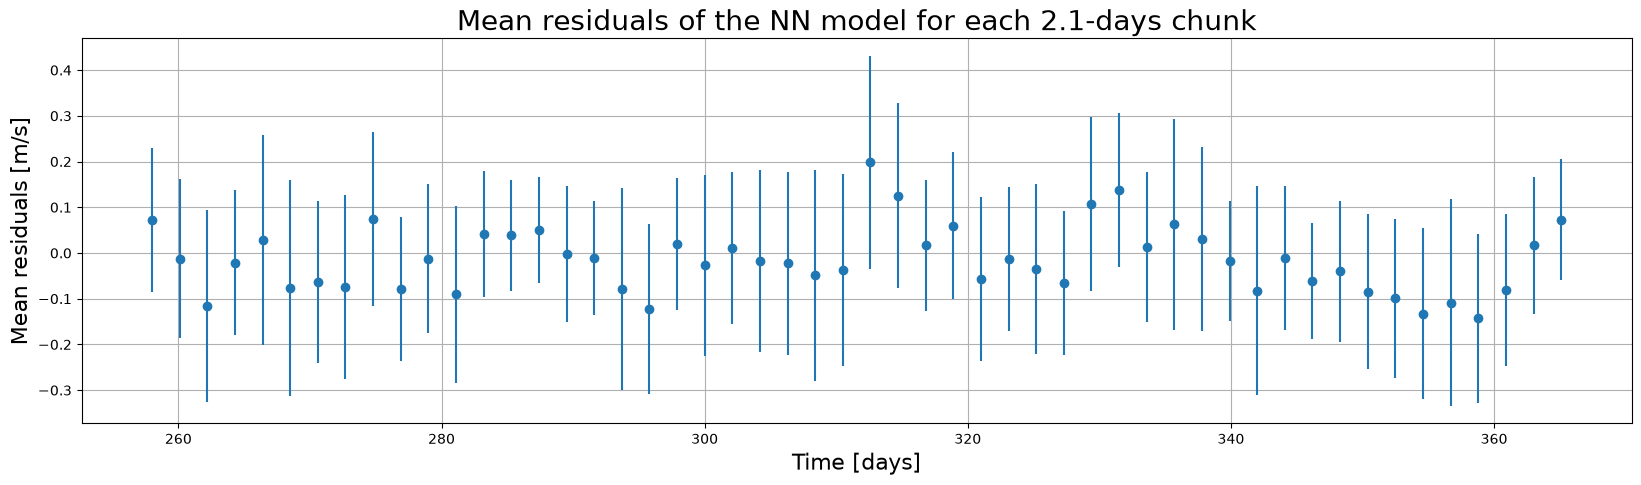

In [121]:
times_test_chunked = times[train_size:-rest_test:chunk_size]  # array of days that correspond to the time where each chunk starts

fig, ax = plt.subplots(figsize=(20, 5))
ax.grid()
ax.set_title(f'Mean residuals of the NN model for each {chunk_size / 10}-days chunk', size=20)

ax.errorbar(times_test_chunked, mean_res_test_nn, std_res_test_nn, color='C0', fmt='o')
ax.set_xlabel('Time [days]', size=16)  # time where the chunk starts
ax.set_ylabel('Mean residuals [m/s]', size=16)

plt.show()

In [122]:
# create flat arrays to ease plots
y_train_pred_nn_flat = np.concatenate(y_train_pred_nn)
y_train_true_nn_flat = np.concatenate(y_train_true_nn)
res_train_nn_flat    = np.concatenate(res_train_nn)

y_test_pred_nn_flat = np.concatenate(y_test_pred_nn)
y_test_true_nn_flat = np.concatenate(y_test_true_nn)
res_test_nn_flat    = np.concatenate(res_test_nn)

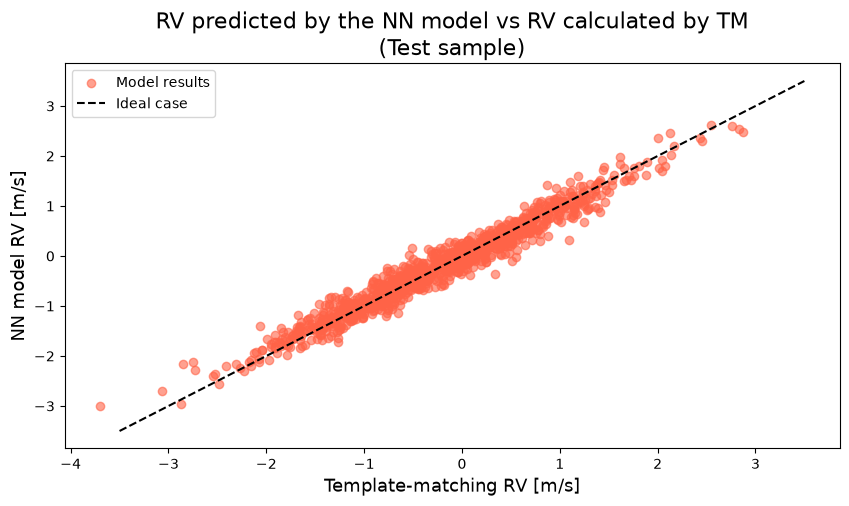

In [123]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('RV predicted by the NN model vs RV calculated by TM\n(Test sample)', size=16)

ax.scatter(y_test_true_nn_flat, y_test_pred_nn_flat, color='tomato', alpha=.6, label='Model results')
ax.plot([-3.5, 3.5], [-3.5, 3.5], linestyle='--', color='k', label='Ideal case')
ax.set_xlabel('Template-matching RV [m/s]', size=13)
ax.set_ylabel('NN model RV [m/s]', size=13)
ax.legend()

plt.show()

In [124]:
# compute means
mean_train = np.mean(res_train_nn_flat)
mean_test = np.mean(res_test_nn_flat)

# compute stds
std_train = np.std(res_train_nn_flat)
std_test = np.std(res_test_nn_flat)

In [125]:
print('---------- Mean of RV residuals ----------')
print(f'Train: {mean_train:.5f} m/s.')
print(f'Test: {mean_test:.5f} m/s.')

print('---------- Std of RV residuals ----------')
print(f'Train: {std_train:.4f} m/s.')
print(f'Test: {std_test:.4f} m/s.')

---------- Mean of RV residuals ----------
Train: 0.00764 m/s.
Test: -0.01475 m/s.
---------- Std of RV residuals ----------
Train: 0.1529 m/s.
Test: 0.1940 m/s.


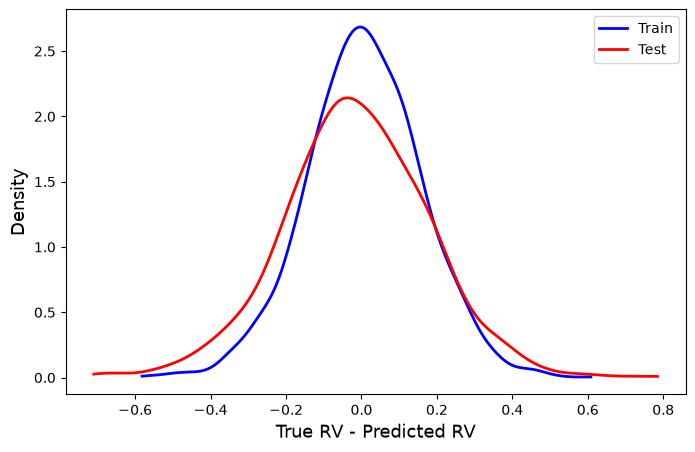

In [126]:
# compare train and test residuals
fig, ax = plt.subplots(figsize=(8, 5))

#ax.hist(res_train, alpha=.5, density=True)
#ax.hist(res_val, alpha=.5, density=True)
#ax.hist(res_test, alpha=.5, density=True)

# Smooth KDE curve
# gaussian_kde: estimates the probability density function of a random variable
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html
kde_train = gaussian_kde(res_train_nn_flat)
x_train = np.linspace(res_train_nn_flat.min(), res_train_nn_flat.max(), 500)

kde_test = gaussian_kde(res_test_nn_flat)
x_test = np.linspace(res_test_nn_flat.min(), res_test_nn_flat.max(), 500)

# Density histograms
ax.plot(x_train, kde_train(x_train), linewidth=2, color='blue', label='Train')
ax.plot(x_test, kde_test(x_test), linewidth=2, color='red', label='Test')

ax.set_xlabel('True RV - Predicted RV', size=13)
ax.set_ylabel('Density', size=13)
ax.legend()

plt.show()